## 1. 실험 목표와 비교 기준

- 이 셀에서 할 일: 이번 노트북의 목표를 한 문단으로 정리합니다.
- 예시 방향: "쇼핑몰 리뷰 감성 분석을 수행하고, 같은 backbone에서 Full Fine-Tuning과 PEFT를 비교한다"처럼 씁니다.
- 함께 적을 내용: 비교 기준은 학습 시간, 정확도, macro F1, 저장 용량, 예측 사례 비교로 잡습니다.


In [1]:
# 필요하다면 아래 설치 명령의 주석을 해제한 뒤 한 번만 실행하세요.
# %pip install -q pandas numpy scikit-learn datasets transformers peft accelerate matplotlib

# 표준 라이브러리
import json
import os
import random
import time
import inspect
from pathlib import Path

# 서드파티 라이브러리
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from IPython.display import display
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

# 토크나이저 경고를 줄이고 표 출력 폭을 넉넉하게 설정합니다.
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
pd.set_option('display.max_colwidth', 160)
pd.set_option('display.max_columns', 20)

# 실험 재현성을 위해 시드를 고정합니다.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

# 현재 사용할 연산 장치를 확인합니다.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'사용 장치: {DEVICE}')
print(f'PyTorch 버전: {torch.__version__}')


c:\Users\amy\Desktop\sprint\sprint_ai07\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


사용 장치: cuda
PyTorch 버전: 2.9.1+cu126


In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 한글 폰트 설정
font_candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic']
available_fonts = {font.name for font in font_manager.fontManager.ttflist}

for font_name in font_candidates:
    if font_name in available_fonts:
        plt.rcParams['font.family'] = font_name
        break

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### 실행 환경 점검

- 이 셀에서는 현재 노트북 커널이 어떤 Python 실행 파일을 쓰는지와 필수 패키지 설치 상태를 먼저 확인합니다.
- 특히 `peft`처럼 터미널 환경과 노트북 커널 환경이 다르면 import 에러가 날 수 있으니, 학습 전에 한 번 점검해 두는 것이 안전합니다.
- 누락 패키지가 보이면 `%pip install ...` 명령을 실행한 뒤 커널을 다시 시작하고 처음부터 순서대로 실행합니다.


In [2]:
import sys
import platform
import importlib.util
from importlib.metadata import PackageNotFoundError, version

import pandas as pd
from IPython.display import display

REQUIRED_PACKAGES = [
    {'package': 'transformers', 'module': 'transformers', 'distribution': 'transformers'},
    {'package': 'datasets', 'module': 'datasets', 'distribution': 'datasets'},
    {'package': 'accelerate', 'module': 'accelerate', 'distribution': 'accelerate'},
    {'package': 'peft', 'module': 'peft', 'distribution': 'peft'},
    {'package': 'torch', 'module': 'torch', 'distribution': 'torch'},
    {'package': 'scikit-learn', 'module': 'sklearn', 'distribution': 'scikit-learn'},
    {'package': 'matplotlib', 'module': 'matplotlib', 'distribution': 'matplotlib'},
]


def get_package_status(module_name, distribution_name):
    installed = importlib.util.find_spec(module_name) is not None
    if not installed:
        return False, None
    try:
        return True, version(distribution_name)
    except PackageNotFoundError:
        return True, '설치됨 (버전 확인 불가)'


env_rows = []
for pkg in REQUIRED_PACKAGES:
    installed, version_text = get_package_status(pkg['module'], pkg['distribution'])
    env_rows.append(
        {
            'package': pkg['package'],
            'module': pkg['module'],
            'installed': installed,
            'version': version_text,
        }
    )

env_df = pd.DataFrame(env_rows)
env_display_df = env_df.rename(
    columns={
        'package': '패키지',
        'module': '모듈',
        'installed': '설치 여부',
        'version': '버전',
    }
)
display(env_display_df)

print('Python 실행 파일:', sys.executable)
print('Python 버전:', sys.version.split()[0])
print('실행 환경:', platform.platform())

missing_packages = env_df.loc[~env_df['installed'], 'package'].tolist()
if missing_packages:
    print()
    print('누락 패키지:', ', '.join(missing_packages))
    print('실행 명령: %pip install -q ' + ' '.join(missing_packages))
    print('설치 후에는 커널을 다시 시작하고 처음부터 순서대로 실행하세요.')
else:
    print()
    print('필수 패키지가 모두 현재 노트북 커널에서 감지되었습니다.')


,패키지,모듈,설치 여부,버전
0,transformers,transformers,True,5.3.0
1,datasets,datasets,True,4.8.3
2,accelerate,accelerate,True,1.13.0
3,peft,peft,True,0.18.1
4,torch,torch,True,2.9.1+cu126
5,scikit-learn,sklearn,True,1.8.0
6,matplotlib,matplotlib,True,3.10.8


Python 실행 파일: c:\Users\amy\Desktop\sprint\sprint_ai07\venv\Scripts\python.exe
Python 버전: 3.11.9
실행 환경: Windows-10-10.0.26100-SP0

필수 패키지가 모두 현재 노트북 커널에서 감지되었습니다.


## 2. 데이터 범위 선택 이유

- 이 셀에서 할 일: 어떤 데이터 범위를 사용할지 먼저 선언합니다.
- 추천 방향: 첫 제출본은 `쇼핑몰 / 01. 패션` 도메인으로 고정하고, 그 이유를 적습니다.
- 함께 적을 내용: 데이터 수가 충분하고, 빈 라벨 비율이 상대적으로 낮으며, 3개 라벨 분포가 비교적 안정적이라는 점을 설명합니다.


In [3]:
# 이번 실험에서 사용할 데이터 범위와 주요 설정값을 고정합니다.
SOURCE_NAME = '쇼핑몰'
DOMAIN_NAME = '01. 패션'
TEXT_COLUMN = 'RawText'
LABEL_COLUMN = 'GeneralPolarity'
MODEL_NAME = 'beomi/KcELECTRA-base'

# 데이터 미리보기에서 사용할 한글 컬럼 이름입니다.
DISPLAY_COLUMN_MAP = {
    'file_name': '파일명',
    'file_path': '파일 경로',
    'source': '출처',
    'domain': '도메인',
    'main_category': '대분류',
    'product_name': '상품명',
    'review_text': '리뷰 텍스트',
    'general_polarity': '감성 값',
    'review_score': '평점',
}

# 디버깅이 필요할 때만 일부 데이터만 사용합니다.
DEBUG_SAMPLE_SIZE = None  # 예: 5000

# 전체 미세조정과 PEFT의 기본 학습 조건을 맞춰 비교합니다.
FULL_NUM_EPOCHS = 2
PEFT_NUM_EPOCHS = 2
FULL_LEARNING_RATE = 2e-5
PEFT_LEARNING_RATE = 2e-5
TRAIN_BATCH_SIZE = 16 if DEVICE == 'cuda' else 8
EVAL_BATCH_SIZE = 32 if DEVICE == 'cuda' else 8

# 감성 라벨을 모델용 정수 인덱스로 변환하기 위한 매핑입니다.
POLARITY_TO_LABEL = {-1: 0, 0: 1, 1: 2}
POLARITY_TO_NAME = {-1: '부정', 0: '중립', 1: '긍정'}
ID2LABEL = {0: '부정', 1: '중립', 2: '긍정'}
LABEL2ID = {'부정': 0, '중립': 1, '긍정': 2}

# 노트북 실행 위치가 달라도 데이터 폴더를 찾을 수 있게 후보 경로를 순서대로 확인합니다.
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR_CANDIDATES = [
    NOTEBOOK_DIR,
    NOTEBOOK_DIR / '미션',
    NOTEBOOK_DIR.parent / '미션',
]
PROJECT_DIR = next(
    (path for path in PROJECT_DIR_CANDIDATES if (path / 'content' / 'review-sentiment-analysis').exists()),
    None,
)
if PROJECT_DIR is None:
    raise FileNotFoundError('review-sentiment-analysis 폴더를 찾지 못했습니다.')

DATA_ROOT = PROJECT_DIR / 'content' / 'review-sentiment-analysis' / SOURCE_NAME / DOMAIN_NAME
OUTPUT_ROOT = PROJECT_DIR / 'outputs' / 'mission13_sentiment'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# 학습 로그 디렉터리와 최종 저장 디렉터리를 분리해 모델 용량을 깔끔하게 비교합니다.
FULL_RUN_DIR = OUTPUT_ROOT / 'full_ft_run'
FULL_EXPORT_DIR = OUTPUT_ROOT / 'full_ft_export'
PEFT_RUN_DIR = OUTPUT_ROOT / 'peft_run'
PEFT_EXPORT_DIR = OUTPUT_ROOT / 'peft_export'
for path in [FULL_RUN_DIR, FULL_EXPORT_DIR, PEFT_RUN_DIR, PEFT_EXPORT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f'프로젝트 경로: {PROJECT_DIR}')
print(f'데이터 경로: {DATA_ROOT}')
print(f'사용 모델: {MODEL_NAME}')
print(f'디버그 샘플 크기: {DEBUG_SAMPLE_SIZE}')


프로젝트 경로: c:\Users\amy\Desktop\sprint\sprint_ai07\미션
데이터 경로: c:\Users\amy\Desktop\sprint\sprint_ai07\미션\content\review-sentiment-analysis\쇼핑몰\01. 패션
사용 모델: beomi/KcELECTRA-base
디버그 샘플 크기: None


## 3. 데이터 파일 구조 확인

- 이 셀에서 할 일: 실제 데이터가 어떤 폴더와 파일 구조로 저장되어 있는지 설명합니다.
- 함께 적을 내용: JSON 파일 하나에 여러 리뷰가 들어 있고, 주요 필드는 `RawText`, `GeneralPolarity`임을 적습니다.
- 여기서는 앞으로 어떤 필드만 사용할지도 함께 선언해 두면 좋습니다.


In [4]:
# 선택한 도메인의 JSON 파일 목록을 수집합니다.
json_paths = sorted(DATA_ROOT.rglob('*.json'))
if not json_paths:
    raise FileNotFoundError(f'JSON 파일을 찾지 못했습니다: {DATA_ROOT}')

print(f'총 JSON 파일 수: {len(json_paths):,}')
print('\n샘플 파일 3개:')
for path in json_paths[:3]:
    print('-', path.relative_to(PROJECT_DIR))

# 첫 번째 파일을 열어 구조와 예시 레코드를 미리 확인합니다.
sample_payload = json.loads(json_paths[0].read_text(encoding='utf-8'))
sample_record = sample_payload[0]

print(f'\n첫 번째 파일 안 리뷰 수: {len(sample_payload):,}')
print('샘플 레코드의 주요 키 확인:')
for key in [TEXT_COLUMN, LABEL_COLUMN, 'MainCategory', 'ProductName', 'Source', 'Domain']:
    print(f'- {key}: {sample_record.get(key)}')


총 JSON 파일 수: 450

샘플 파일 3개:
- content\review-sentiment-analysis\쇼핑몰\01. 패션\1-1. 여성의류\1-1.여성의류(1).json
- content\review-sentiment-analysis\쇼핑몰\01. 패션\1-1. 여성의류\1-1.여성의류(10).json
- content\review-sentiment-analysis\쇼핑몰\01. 패션\1-1. 여성의류\1-1.여성의류(100).json

첫 번째 파일 안 리뷰 수: 100
샘플 레코드의 주요 키 확인:
- RawText: 가격이 착하고 디자인이 예쁩니다
- GeneralPolarity: 1
- MainCategory: 여성의류
- ProductName: OO 플** 베스트 풀코디 3종
- Source: 쇼핑몰
- Domain: 패션


## 4. 데이터 로드 전략

- 이 셀에서 할 일: 여러 JSON 파일을 읽어서 하나의 분석용 테이블로 합치는 계획을 적습니다.
- 함께 적을 내용: 파일 반복 로드, 필요한 컬럼만 추출, 데이터프레임 형태로 정리한다는 흐름을 씁니다.
- 이 단계에서는 아직 복잡한 전처리보다 `학습 가능한 형태로 모으는 것`이 목적이라는 점을 적어 주세요.


In [5]:
# 여러 JSON 파일을 하나의 데이터프레임으로 합치기 위한 함수를 정의합니다.
def load_review_records(paths):
    records = []
    for path in paths:
        payload = json.loads(path.read_text(encoding='utf-8'))
        for row in payload:
            records.append(
                {
                    'file_name': path.name,
                    'file_path': str(path.relative_to(PROJECT_DIR)),
                    'source': row.get('Source', SOURCE_NAME),
                    'domain': row.get('Domain'),
                    'main_category': row.get('MainCategory'),
                    'product_name': row.get('ProductName'),
                    'review_text': row.get(TEXT_COLUMN),
                    'general_polarity': row.get(LABEL_COLUMN),
                    'review_score': row.get('ReviewScore'),
                }
            )
    return pd.DataFrame(records)

# 모든 파일을 읽어 원본 테이블을 만듭니다.
df_raw = load_review_records(json_paths)

# 필요할 때만 디버그 샘플을 사용해 빠르게 구조를 점검합니다.
if DEBUG_SAMPLE_SIZE is not None:
    df_raw = (
        df_raw.sample(n=min(DEBUG_SAMPLE_SIZE, len(df_raw)), random_state=SEED)
        .reset_index(drop=True)
    )

print(f'원본 데이터 크기: {df_raw.shape}')
display(df_raw.head().rename(columns=DISPLAY_COLUMN_MAP))


원본 데이터 크기: (44996, 9)


,파일명,파일 경로,출처,도메인,대분류,상품명,리뷰 텍스트,감성 값,평점
0,1-1.여성의류(1).json,content\review-sentiment-analysis\쇼핑몰\01. 패션\1-1. 여성의류\1-1.여성의류(1).json,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,가격이 착하고 디자인이 예쁩니다,1,100
1,1-1.여성의류(1).json,content\review-sentiment-analysis\쇼핑몰\01. 패션\1-1. 여성의류\1-1.여성의류(1).json,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,싸고 디자인이 예뻐요. . 정말 가성비 가심비 입니다,1,100
2,1-1.여성의류(1).json,content\review-sentiment-analysis\쇼핑몰\01. 패션\1-1. 여성의류\1-1.여성의류(1).json,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,편하고 디자인이 예뻐요 가격도 좋아요 시원해요 빨리 마르고 이것만 입게되요,1,100
3,1-1.여성의류(1).json,content\review-sentiment-analysis\쇼핑몰\01. 패션\1-1. 여성의류\1-1.여성의류(1).json,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,너무 착한가격에 감사합니다 윈하는 색은 없지만,1,100
4,1-1.여성의류(1).json,content\review-sentiment-analysis\쇼핑몰\01. 패션\1-1. 여성의류\1-1.여성의류(1).json,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,가격이 너무 좋아서 블랙 구매했습니다 그런데 소재도 맘에 들어 흰색도 구매했습니다,1,100


## 5. 전처리 기준 정의

- 이 셀에서 할 일: 어떤 샘플을 유지하고 어떤 샘플을 제거할지 기준을 먼저 적습니다.
- 꼭 포함할 내용: 빈 라벨 제거, 빈 텍스트 제거 여부, 공백 정리, 중복 리뷰 확인 여부.
- 이번 노트북에서는 `review_text + general_polarity`가 완전히 같은 경우만 중복으로 제거합니다. 데이터 누수 위험을 줄인다는 장점이 있지만, 실제로 반복 작성된 짧은 리뷰까지 빠질 수 있다는 점은 해석에 함께 적어 두면 좋습니다.
- 과한 전처리보다 최소 전처리로 시작하는 이유도 짧게 설명하면 좋습니다.


In [6]:
# 리뷰 텍스트를 최소한으로 정리하는 함수를 만듭니다.
def clean_text(text):
    if pd.isna(text):
        return None
    text = str(text)
    text = ' '.join(text.split())  # 연속 공백과 개행을 정리합니다.
    return text.strip()

# 원본을 복사해 전처리용 데이터프레임을 만듭니다.
df_clean = df_raw.copy()
before_count = len(df_clean)

# 텍스트와 라벨 컬럼을 정리합니다.
df_clean['review_text'] = df_clean['review_text'].map(clean_text)
df_clean['general_polarity'] = pd.to_numeric(df_clean['general_polarity'], errors='coerce')

# 라벨이 없거나 텍스트가 비어 있는 샘플은 제거합니다.
df_clean = df_clean.dropna(subset=['review_text', 'general_polarity'])
df_clean = df_clean[df_clean['review_text'].str.len() > 0]

# 과제에서 사용할 라벨 값(-1, 0, 1)만 남깁니다.
df_clean = df_clean[df_clean['general_polarity'].isin(POLARITY_TO_LABEL)]

# 완전히 같은 텍스트와 라벨 조합은 중복으로 보고 제거합니다.
duplicate_count = df_clean.duplicated(subset=['review_text', 'general_polarity']).sum()
df_clean = df_clean.drop_duplicates(subset=['review_text', 'general_polarity']).reset_index(drop=True)

after_count = len(df_clean)
print(f'전처리 전 샘플 수: {before_count:,}')
print(f'중복 제거 수: {duplicate_count:,}')
print(f'전처리 후 샘플 수: {after_count:,}')
display(df_clean.head().rename(columns=DISPLAY_COLUMN_MAP))


전처리 전 샘플 수: 44,996
중복 제거 수: 2
전처리 후 샘플 수: 44,396


,파일명,파일 경로,출처,도메인,대분류,상품명,리뷰 텍스트,감성 값,평점
0,1-1.여성의류(1).json,content\review-sentiment-analysis\쇼핑몰\01. 패션\1-1. 여성의류\1-1.여성의류(1).json,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,가격이 착하고 디자인이 예쁩니다,1.0,100
1,1-1.여성의류(1).json,content\review-sentiment-analysis\쇼핑몰\01. 패션\1-1. 여성의류\1-1.여성의류(1).json,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,싸고 디자인이 예뻐요. . 정말 가성비 가심비 입니다,1.0,100
2,1-1.여성의류(1).json,content\review-sentiment-analysis\쇼핑몰\01. 패션\1-1. 여성의류\1-1.여성의류(1).json,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,편하고 디자인이 예뻐요 가격도 좋아요 시원해요 빨리 마르고 이것만 입게되요,1.0,100
3,1-1.여성의류(1).json,content\review-sentiment-analysis\쇼핑몰\01. 패션\1-1. 여성의류\1-1.여성의류(1).json,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,너무 착한가격에 감사합니다 윈하는 색은 없지만,1.0,100
4,1-1.여성의류(1).json,content\review-sentiment-analysis\쇼핑몰\01. 패션\1-1. 여성의류\1-1.여성의류(1).json,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,가격이 너무 좋아서 블랙 구매했습니다 그런데 소재도 맘에 들어 흰색도 구매했습니다,1.0,100


## 6. 라벨 매핑과 분포 확인

- 이 셀에서 할 일: 감성 라벨 `-1`, `0`, `1`을 모델 학습용 클래스 인덱스로 어떻게 바꿀지 설명합니다.
- 함께 적을 내용: 부정, 중립, 긍정의 개수와 비율을 확인하고, 클래스 불균형이 어느 정도인지 간단히 해석합니다.
- 여기서 이번 과제는 2분류가 아니라 3분류로 진행한다고 분명히 적어 두는 것이 좋습니다.


모델링에 사용할 총 샘플 수: 44,396


,감성 라벨,개수,비율
0,부정,9263,0.208645
1,중립,8683,0.195581
2,긍정,26450,0.595774


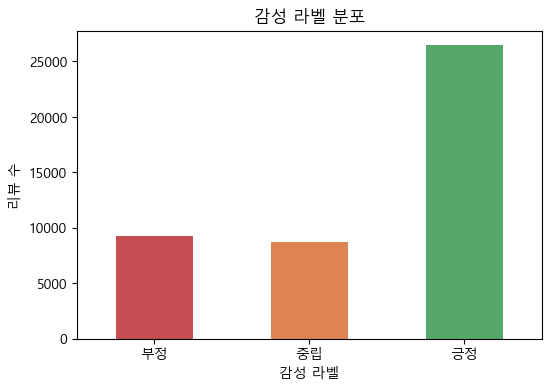

In [19]:
# 모델 학습에 사용할 라벨 인덱스와 라벨 이름을 추가합니다.
df_model = df_clean.copy()
df_model['general_polarity'] = df_model['general_polarity'].astype(int)
df_model['label'] = df_model['general_polarity'].map(POLARITY_TO_LABEL)
df_model['label_name'] = df_model['general_polarity'].map(POLARITY_TO_NAME)

# 라벨 분포를 순서대로 확인하기 위해 집계 테이블을 만듭니다.
label_order = ['부정', '중립', '긍정']
label_stats = (
    df_model['label_name']
    .value_counts()
    .reindex(label_order)
    .rename_axis('label_name')
    .reset_index(name='count')
)
label_stats['ratio'] = label_stats['count'] / len(df_model)
label_stats_display = label_stats.rename(
    columns={
        'label_name': '감성 라벨',
        'count': '개수',
        'ratio': '비율',
    }
)

print(f'모델링에 사용할 총 샘플 수: {len(df_model):,}')
display(label_stats_display)

# 클래스 분포를 막대그래프로 확인합니다.
ax = label_stats.plot(
    kind='bar',
    x='label_name',
    y='count',
    legend=False,
    rot=0,
    figsize=(6, 4),
    color=['#c44e52', '#dd8452', '#55a868'],
)
ax.set_title('감성 라벨 분포')
ax.set_xlabel('감성 라벨')
ax.set_ylabel('리뷰 수')
plt.show()


## 7. 학습용 데이터 분할

- 이 셀에서 할 일: train / validation / test 또는 train / test 분할 방식을 설명합니다.
- 꼭 포함할 내용: Full Fine-Tuning과 PEFT가 같은 분할 데이터를 써야 공정 비교가 가능하다는 점.
- 가능하면 stratified split으로 라벨 비율을 유지하겠다는 계획도 적습니다.


In [8]:
# 같은 기준으로 전체 미세조정과 PEFT를 비교하기 위해 데이터를 한 번만 분할합니다.
train_df, test_df = train_test_split(
    df_model,
    test_size=0.1,
    stratify=df_model['label'],
    random_state=SEED,
)
train_df, valid_df = train_test_split(
    train_df,
    test_size=0.111111,  # 최종 비율이 학습 80 / 검증 10 / 테스트 10이 되도록 맞춥니다.
    stratify=train_df['label'],
    random_state=SEED,
)

# 이후 셀에서 인덱스 문제를 피하기 위해 각각 인덱스를 다시 정리합니다.
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# 분할 결과와 라벨 분포를 표로 확인합니다.
def summarize_split(df, split_name):
    summary = (
        df['label_name']
        .value_counts()
        .reindex(['부정', '중립', '긍정'])
        .rename(split_name)
        .to_frame()
        .T
    )
    summary['전체'] = len(df)
    return summary

split_summary = pd.concat(
    [
        summarize_split(train_df, '학습'),
        summarize_split(valid_df, '검증'),
        summarize_split(test_df, '테스트'),
    ]
)
display(split_summary)


label_name,부정,중립,긍정,전체
학습,7410,6946,21160,35516
검증,926,869,2645,4440
테스트,927,868,2645,4440


## 8. 토크나이저와 사전학습 모델 선택 이유

- 이 셀에서 할 일: 어떤 한국어 분류 모델 backbone을 사용할지와 그 이유를 적습니다.
- 함께 적을 내용: 한국어 리뷰 문장 분류에 적합한 모델이라는 점, 그리고 Full FT와 PEFT에서 같은 backbone을 유지해 비교 변수는 학습 방식만 남긴다는 점.
- 베이스라인을 참고했더라도 그대로 복사한 것이 아니라 비교 설계 관점에서 선택했다는 흐름으로 쓰면 좋습니다.


In [9]:
# 전체 미세조정과 PEFT 모두 같은 backbone을 사용하도록 토크나이저를 먼저 불러옵니다.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

print(f'토크나이저 클래스: {type(tokenizer).__name__}')
print(f'어휘 사전 크기: {tokenizer.vocab_size:,}')

# 리뷰 한 문장을 토큰화해 입력 형태를 간단히 확인합니다.
sample_text = train_df.loc[0, 'review_text']
encoded_example = tokenizer(sample_text)
print('샘플 리뷰:')
print(sample_text)
print()
print('토큰 개수:', len(encoded_example['input_ids']))
print('앞쪽 토큰 ID:', encoded_example['input_ids'][:20])


토크나이저 클래스: TokenizersBackend
어휘 사전 크기: 30,000
샘플 리뷰:
색상, 모양 정말 좋고 , 신어보니 따뜻하고 착화감 최고임 신어보고 나서 주변 사람들에게 강력 추천 많이 많이 했어요 좋은건 함께 해야죠~~~

토큰 개수: 31
앞쪽 토큰 ID: [3437, 400, 16, 4163, 939, 8330, 1892, 683, 2707, 276, 8655, 393, 2212, 557, 785, 2018, 570, 683, 20621, 2831]


## 9. 토큰화와 입력 형식 설계

- 이 셀에서 할 일: 리뷰 텍스트를 모델 입력으로 바꾸는 과정을 설명합니다.
- 함께 적을 내용: 최대 길이 설정, truncation, padding 전략, 라벨 컬럼 포함 여부.
- 여기서는 길이 분포를 확인한 뒤 max length를 정한다는 계획을 한 줄로 적어도 좋습니다.


In [10]:
# 학습 데이터 일부를 이용해 적절한 최대 길이를 추정합니다.
length_sample_size = min(2000, len(train_df))
length_sample_texts = train_df['review_text'].sample(n=length_sample_size, random_state=SEED).tolist()
lengths = [len(tokenizer(text, truncation=False)['input_ids']) for text in length_sample_texts]

MAX_LENGTH = int(np.percentile(lengths, 95))
MAX_LENGTH = max(64, min(MAX_LENGTH, 256))

print(f'길이 샘플 수: {len(lengths):,}')
print(f'평균 토큰 길이: {np.mean(lengths):.1f}')
print(f'95퍼센타일 기준 최대 길이: {MAX_LENGTH}')

# pandas 데이터프레임을 Hugging Face Dataset 형식으로 변환합니다.
hf_dataset = DatasetDict(
    {
        'train': Dataset.from_pandas(train_df[['review_text', 'label']], preserve_index=False),
        'validation': Dataset.from_pandas(valid_df[['review_text', 'label']], preserve_index=False),
        'test': Dataset.from_pandas(test_df[['review_text', 'label']], preserve_index=False),
    }
)

# 토크나이저가 배치 단위로 동작할 수 있도록 함수를 정의합니다.
def tokenize_batch(batch):
    return tokenizer(batch['review_text'], truncation=True, max_length=MAX_LENGTH)


tokenized_datasets = hf_dataset.map(tokenize_batch, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(['review_text'])
tokenized_datasets = tokenized_datasets.rename_column('label', 'labels')
tokenized_datasets.set_format('torch')

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# Trainer가 매 evaluation 단계에서 사용할 평가지표를 정의합니다.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }


# 같은 형식의 학습 인자를 재사용할 수 있도록 함수로 정리합니다.
def build_training_args(output_dir, run_name, num_train_epochs, learning_rate):
    training_kwargs = {
        'output_dir': str(output_dir),
        'run_name': run_name,
        'num_train_epochs': num_train_epochs,
        'learning_rate': learning_rate,
        'per_device_train_batch_size': TRAIN_BATCH_SIZE,
        'per_device_eval_batch_size': EVAL_BATCH_SIZE,
        'save_strategy': 'epoch',
        'logging_strategy': 'steps',
        'logging_steps': 50,
        'save_total_limit': 2,
        'load_best_model_at_end': True,
        'metric_for_best_model': 'f1_macro',
        'greater_is_better': True,
        'weight_decay': 0.01,
        'report_to': [],
        'fp16': torch.cuda.is_available(),
        'seed': SEED,
    }

    # transformers 버전에 따라 evaluation_strategy / eval_strategy 중 하나를 선택합니다.
    signature = inspect.signature(TrainingArguments.__init__)
    if 'evaluation_strategy' in signature.parameters:
        training_kwargs['evaluation_strategy'] = 'epoch'
    else:
        training_kwargs['eval_strategy'] = 'epoch'

    return TrainingArguments(**training_kwargs)


# 같은 backbone을 쓰는 분류 모델 생성 함수를 따로 정의해 재사용합니다.
def make_classification_model():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(ID2LABEL),
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )


# Trainer 생성 로직도 함수로 묶어 두 모델에 공통 사용합니다.
def build_trainer(model, training_args):
    trainer_kwargs = {
        'model': model,
        'args': training_args,
        'train_dataset': tokenized_datasets['train'],
        'eval_dataset': tokenized_datasets['validation'],
        'data_collator': data_collator,
        'compute_metrics': compute_metrics,
    }

    # transformers 버전에 따라 tokenizer / processing_class 중 하나를 전달합니다.
    trainer_signature = inspect.signature(Trainer.__init__)
    if 'tokenizer' in trainer_signature.parameters:
        trainer_kwargs['tokenizer'] = tokenizer
    else:
        trainer_kwargs['processing_class'] = tokenizer

    return Trainer(**trainer_kwargs)


# 예측 결과를 편하게 재사용할 수 있도록 helper를 만듭니다.
def get_prediction_outputs(trainer, split_name='test'):
    pred_output = trainer.predict(tokenized_datasets[split_name])
    pred_ids = np.argmax(pred_output.predictions, axis=-1)
    true_ids = pred_output.label_ids
    return pred_ids, true_ids, pred_output.metrics


# 클래스별 정밀도 / 재현율 / F1 표만 따로 보기 쉽게 정리합니다.
def extract_class_report(report_df):
    class_labels = [ID2LABEL[i] for i in range(len(ID2LABEL))]
    available_labels = [label for label in class_labels if label in report_df.index]
    return (
        report_df.loc[available_labels, ['precision', 'recall', 'f1-score', 'support']]
        .reset_index()
        .rename(
            columns={
                'index': '라벨',
                'precision': '정밀도',
                'recall': '재현율',
                'f1-score': 'F1',
                'support': '개수',
            }
        )
    )


# 혼동 행렬에서 자주 헷갈린 라벨 조합만 뽑아 봅니다.
def summarize_confusion_pairs(conf_mat, id2label):
    rows = []
    for true_idx, row in enumerate(conf_mat):
        for pred_idx, count in enumerate(row):
            if true_idx == pred_idx or count == 0:
                continue
            rows.append(
                {
                    '실제 라벨': id2label[true_idx],
                    '예측 라벨': id2label[pred_idx],
                    '건수': int(count),
                }
            )

    if not rows:
        return pd.DataFrame(columns=['실제 라벨', '예측 라벨', '건수'])

    return pd.DataFrame(rows).sort_values('건수', ascending=False).reset_index(drop=True)


# backbone 내부 Linear 층 이름을 보고 LoRA target modules를 자동으로 선택합니다.
def choose_lora_target_modules(model):
    linear_suffixes = sorted(
        {
            name.split('.')[-1]
            for name, module in model.named_modules()
            if isinstance(module, torch.nn.Linear)
        }
    )
    available_set = set(linear_suffixes)
    candidate_groups = [
        ['query', 'key', 'value'],
        ['q_proj', 'k_proj', 'v_proj'],
        ['query_key_value'],
        ['c_attn'],
        ['Wqkv'],
    ]

    for group in candidate_groups:
        if all(target in available_set for target in group):
            return group, linear_suffixes

    raise ValueError(
        'LoRA를 적용할 attention projection 모듈을 자동으로 찾지 못했습니다. '
        + f'감지된 Linear suffix: {", ".join(linear_suffixes)}'
    )


# 분류 헤드를 함께 저장해야 하는 경우를 대비해 가능한 이름을 확인합니다.
def choose_modules_to_save(model):
    available_suffixes = {name.split('.')[-1] for name, _ in model.named_modules()}
    candidate_names = ['classifier', 'score', 'classification_head']
    selected = [name for name in candidate_names if name in available_suffixes]
    return selected or None


# 실제로 몇 개 모듈이 LoRA 대상에 매칭되는지도 함께 확인합니다.
def count_target_module_matches(model, target_modules):
    target_module_set = set(target_modules)
    return [
        name
        for name, module in model.named_modules()
        if isinstance(module, torch.nn.Linear) and name.split('.')[-1] in target_module_set
    ]


# 토크나이저 파일을 제외한 모델 아티팩트 크기를 계산합니다.
def get_model_file_size_mb(path):
    ignore_names = {
        'tokenizer.json',
        'tokenizer_config.json',
        'special_tokens_map.json',
        'vocab.txt',
        'merges.txt',
        'training_args.bin',
    }
    total_bytes = 0
    for file_path in Path(path).rglob('*'):
        if file_path.is_file() and file_path.name not in ignore_names:
            total_bytes += file_path.stat().st_size
    return total_bytes / (1024 ** 2)


display(tokenized_datasets)


길이 샘플 수: 2,000
평균 토큰 길이: 32.4
95퍼센타일 기준 최대 길이: 73


Map: 100%|██████████| 4440/4440 [00:00<00:00, 4593.17 examples/s]


DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 35516
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 4440
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 4440
    })
})

## 10. Full Fine-Tuning 실험 설계

- 이 셀에서 할 일: Full Fine-Tuning에서 어떤 학습 조건으로 실험할지 정리합니다.
- 포함할 내용: epoch, batch size, learning rate, evaluation 전략, 저장 전략, 측정할 지표.
- 같은 backbone, 같은 데이터 분할, 같은 평가지표를 유지해서 `비교 가능한 기준점`을 만드는 것이 이번 실험의 핵심이라고 적어 두면 좋습니다.
- 결과 해석 단계에서 클래스별 precision, recall, F1도 함께 보겠다고 미리 적어 두면 뒤쪽 결과 셀과 연결이 자연스럽습니다.


In [11]:
# 전체 미세조정용 모델과 학습 인자를 준비합니다.
full_model = make_classification_model()
full_args = build_training_args(
    output_dir=FULL_RUN_DIR,
    run_name='mission13_full_ft',
    num_train_epochs=FULL_NUM_EPOCHS,
    learning_rate=FULL_LEARNING_RATE,
)
trainer_full = build_trainer(full_model, full_args)

# 학습 시간을 비교하기 위해 시작/종료 시각을 기록합니다.
full_train_start = time.perf_counter()
full_train_result = trainer_full.train()
FULL_TRAIN_SECONDS = time.perf_counter() - full_train_start

full_train_summary = pd.DataFrame(
    [
        {
            '학습 손실': full_train_result.training_loss,
            '전체 스텝 수': trainer_full.state.global_step,
        }
    ]
)
display(full_train_summary)
print(f'전체 미세조정 학습 시간(초): {FULL_TRAIN_SECONDS:,.2f}')
print('최적 체크포인트:', trainer_full.state.best_model_checkpoint)

# 비교용 모델 파일은 별도 export 디렉터리에 저장합니다.
trainer_full.save_model(str(FULL_EXPORT_DIR))
tokenizer.save_pretrained(str(FULL_EXPORT_DIR))


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2333.25it/s]
ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:t

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.296747,0.285679,0.879955,0.839223
2,0.224153,0.307855,0.881306,0.840316


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.42it/s]
There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.la

,학습 손실,전체 스텝 수
0,0.310551,4440


전체 미세조정 학습 시간(초): 443.99
최적 체크포인트: c:\Users\amy\Desktop\sprint\sprint_ai07\미션\outputs\mission13_sentiment\full_ft_run\checkpoint-4440


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.12s/it]


('c:\\Users\\amy\\Desktop\\sprint\\sprint_ai07\\미션\\outputs\\mission13_sentiment\\full_ft_export\\tokenizer_config.json',
 'c:\\Users\\amy\\Desktop\\sprint\\sprint_ai07\\미션\\outputs\\mission13_sentiment\\full_ft_export\\tokenizer.json')

## 11. Full Fine-Tuning 결과 정리

- 이 셀에서 할 일: Full FT 학습 후 얻은 주요 결과를 적습니다.
- 포함할 내용: 학습 시간, 정확도, macro F1, confusion matrix 여부, 예측 결과 해석.
- 숫자만 적지 말고 어떤 라벨에서 잘 맞고 어떤 라벨에서 헷갈리는지도 한두 문장으로 적습니다.
- 가능하면 클래스별 precision, recall, F1과 주요 오분류 조합까지 함께 보고, 왜 그런 혼동이 생겼는지 짧게 해석하면 보고서 완성도가 올라갑니다.


,테스트 손실,테스트 정확도,테스트 매크로 F1,평가 시간(초),초당 샘플 수,초당 스텝 수
0,0.298337,0.886261,0.847068,5.983,742.103,23.232


,라벨,정밀도,재현율,F1,개수
0,부정,0.892045,0.846818,0.868843,927.0
1,중립,0.701075,0.751152,0.725250,868.0
2,긍정,0.949810,0.944423,0.947109,2645.0


,정밀도,재현율,F1,개수
부정,0.892045,0.846818,0.868843,927.000000
중립,0.701075,0.751152,0.725250,868.000000
긍정,0.949810,0.944423,0.947109,2645.000000
정확도,0.886261,0.886261,0.886261,0.886261
매크로 평균,0.847644,0.847464,0.847068,4440.000000
가중 평균,0.889123,0.886261,0.887396,4440.000000


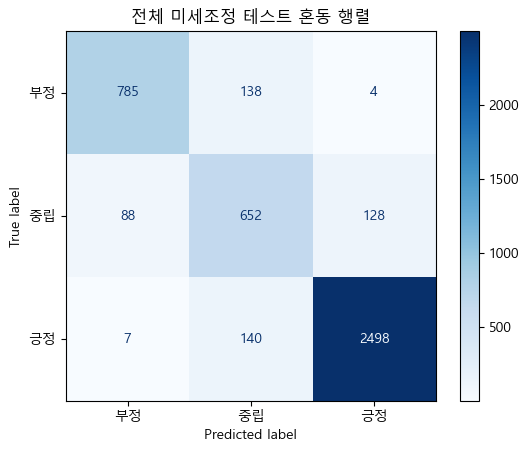

전체 미세조정 주요 오분류 조합:


,실제 라벨,예측 라벨,건수
0,긍정,중립,140
1,부정,중립,138
2,중립,긍정,128
3,중립,부정,88
4,긍정,부정,7
5,부정,긍정,4


전체 미세조정 결과가 비교용 변수에 저장되었습니다.


In [20]:
# 테스트 셋 기준으로 전체 미세조정 모델의 성능을 계산합니다.
full_pred_ids, test_true_ids, full_test_metrics = get_prediction_outputs(trainer_full, split_name='test')

# 상세 지표와 혼동 행렬을 같이 확인합니다.
full_report = pd.DataFrame(
    classification_report(
        test_true_ids,
        full_pred_ids,
        target_names=[ID2LABEL[i] for i in range(len(ID2LABEL))],
        digits=4,
        output_dict=True,
        zero_division=0,
    )
).T
full_class_metrics = extract_class_report(full_report)
full_metric_display = pd.DataFrame([full_test_metrics]).rename(
    columns={
        'test_loss': '테스트 손실',
        'test_accuracy': '테스트 정확도',
        'test_f1_macro': '테스트 매크로 F1',
        'test_runtime': '평가 시간(초)',
        'test_samples_per_second': '초당 샘플 수',
        'test_steps_per_second': '초당 스텝 수',
    }
)
full_report_display = full_report.rename(
    columns={
        'precision': '정밀도',
        'recall': '재현율',
        'f1-score': 'F1',
        'support': '개수',
    },
    index={
        'accuracy': '정확도',
        'macro avg': '매크로 평균',
        'weighted avg': '가중 평균',
    },
)

display(full_metric_display)
display(full_class_metrics)
display(full_report_display)

full_cm = confusion_matrix(test_true_ids, full_pred_ids)
ConfusionMatrixDisplay(
    confusion_matrix=full_cm,
    display_labels=[ID2LABEL[i] for i in range(len(ID2LABEL))],
).plot(cmap='Blues', values_format='d')
plt.title('전체 미세조정 테스트 혼동 행렬')
plt.show()

full_confusion_pairs = summarize_confusion_pairs(full_cm, ID2LABEL)
if not full_confusion_pairs.empty:
    print('전체 미세조정 주요 오분류 조합:')
    display(full_confusion_pairs.head(10))
else:
    print('전체 미세조정은 테스트 셋에서 오분류가 없습니다.')

# 전체 미세조정 결과를 이후 비교 셀에서 재사용할 수 있게 딕셔너리로 정리합니다.
FULL_MODEL_SIZE_MB = get_model_file_size_mb(FULL_EXPORT_DIR)
full_results = {
    'method': '전체 미세조정 (Full FT)',
    'train_seconds': FULL_TRAIN_SECONDS,
    'accuracy': full_test_metrics['test_accuracy'],
    'f1_macro': full_test_metrics['test_f1_macro'],
    'saved_artifact_mb': FULL_MODEL_SIZE_MB,
    'artifact_scope': '전체 모델 가중치',
}
print('전체 미세조정 결과가 비교용 변수에 저장되었습니다.')


## 12. PEFT 적용 이유와 설정

- 이 셀에서 할 일: 왜 PEFT를 적용하는지와 어떤 방식으로 적용할지 설명합니다.
- 포함할 내용: 파라미터 효율성, 저장 용량 절감 기대, 짧은 학습 시간 기대, 그리고 LoRA 같은 설정 요소의 의미.
- 여기서도 backbone은 동일하게 유지하고, 달라지는 것은 학습 방식이라는 점을 다시 강조합니다.
- 추가로 `target_modules`는 모델 내부 모듈 이름에 따라 달라질 수 있으므로, 자동 감지 결과를 확인하고 적용했다는 점을 적어 두면 더 설득력 있습니다.


In [13]:
# PEFT 실험을 위해 LoRA 설정을 불러옵니다.
try:
    from peft import LoraConfig, TaskType, get_peft_model
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        '현재 노트북 커널에서 `peft` 패키지를 찾지 못했습니다. '
        '위의 실행 환경 점검 셀을 확인한 뒤 `%pip install -q peft accelerate`를 실행하고 '
        '커널을 다시 시작하세요.'
    ) from exc

# 같은 backbone에 LoRA 어댑터만 덧붙여 학습합니다.
peft_base_model = make_classification_model()
lora_target_modules, available_linear_suffixes = choose_lora_target_modules(peft_base_model)
matched_lora_modules = count_target_module_matches(peft_base_model, lora_target_modules)
modules_to_save = choose_modules_to_save(peft_base_model)

print('선택된 LoRA 대상 모듈:', lora_target_modules)
print('감지된 Linear 계층 이름:', available_linear_suffixes)
print('매칭된 모듈 수:', len(matched_lora_modules))
print('매칭 예시:', matched_lora_modules[:10])
print('추가로 저장할 분류 헤드:', modules_to_save)

lora_kwargs = {
    'task_type': TaskType.SEQ_CLS,
    'r': 8,
    'lora_alpha': 16,
    'lora_dropout': 0.1,
    'target_modules': lora_target_modules,
    'bias': 'none',
}
if modules_to_save is not None:
    lora_kwargs['modules_to_save'] = modules_to_save

lora_config = LoraConfig(**lora_kwargs)
peft_model = get_peft_model(peft_base_model, lora_config)
peft_model.print_trainable_parameters()

peft_args = build_training_args(
    output_dir=PEFT_RUN_DIR,
    run_name='mission13_peft',
    num_train_epochs=PEFT_NUM_EPOCHS,
    learning_rate=PEFT_LEARNING_RATE,
)
trainer_peft = build_trainer(peft_model, peft_args)

# PEFT 학습 시간도 같은 방식으로 측정합니다.
peft_train_start = time.perf_counter()
peft_train_result = trainer_peft.train()
PEFT_TRAIN_SECONDS = time.perf_counter() - peft_train_start

peft_train_summary = pd.DataFrame(
    [
        {
            '학습 손실': peft_train_result.training_loss,
            '전체 스텝 수': trainer_peft.state.global_step,
        }
    ]
)
display(peft_train_summary)
print(f'PEFT 학습 시간(초): {PEFT_TRAIN_SECONDS:,.2f}')
print('최적 체크포인트:', trainer_peft.state.best_model_checkpoint)

# 어댑터 기반 모델도 별도 export 디렉터리에 저장합니다.
trainer_peft.save_model(str(PEFT_EXPORT_DIR))
tokenizer.save_pretrained(str(PEFT_EXPORT_DIR))


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6379.83it/s]
ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:t

선택된 LoRA 대상 모듈: ['query', 'key', 'value']
감지된 Linear 계층 이름: ['dense', 'key', 'out_proj', 'query', 'value']
매칭된 모듈 수: 36
매칭 예시: ['electra.encoder.layer.0.attention.self.query', 'electra.encoder.layer.0.attention.self.key', 'electra.encoder.layer.0.attention.self.value', 'electra.encoder.layer.1.attention.self.query', 'electra.encoder.layer.1.attention.self.key', 'electra.encoder.layer.1.attention.self.value', 'electra.encoder.layer.2.attention.self.query', 'electra.encoder.layer.2.attention.self.key', 'electra.encoder.layer.2.attention.self.value', 'electra.encoder.layer.3.attention.self.query']
추가로 저장할 분류 헤드: ['classifier']
trainable params: 1,035,267 || all params: 110,118,918 || trainable%: 0.9401


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.470563,0.439240,0.817568,0.718972
2,0.396745,0.421301,0.822748,0.730969


,학습 손실,전체 스텝 수
0,0.499071,4440


PEFT 학습 시간(초): 548.30
최적 체크포인트: c:\Users\amy\Desktop\sprint\sprint_ai07\미션\outputs\mission13_sentiment\peft_run\checkpoint-4440


('c:\\Users\\amy\\Desktop\\sprint\\sprint_ai07\\미션\\outputs\\mission13_sentiment\\peft_export\\tokenizer_config.json',
 'c:\\Users\\amy\\Desktop\\sprint\\sprint_ai07\\미션\\outputs\\mission13_sentiment\\peft_export\\tokenizer.json')

## 13. PEFT 실험 결과 정리

- 이 셀에서 할 일: PEFT 학습 후 얻은 주요 결과를 Full FT와 같은 기준으로 적습니다.
- 포함할 내용: 학습 시간, 정확도, macro F1, 저장 용량, 예측 결과 해석.
- 이 단계에서는 `성능이 얼마나 유지되었는지`와 `효율 측면에서 어떤 이점이 있었는지`를 중심으로 적으면 좋습니다.
- 저장 용량을 적을 때는 이 값이 `adapter artifact` 기준인지, 전체 backbone까지 포함한 값이 아닌지 함께 적어 두면 해석이 더 정확해집니다.


,테스트 손실,테스트 정확도,테스트 매크로 F1,평가 시간(초),초당 샘플 수,초당 스텝 수
0,0.411782,0.828378,0.743131,8.6398,513.899,16.088


,라벨,정밀도,재현율,F1,개수
0,부정,0.736000,0.893204,0.807018,927.0
1,중립,0.617496,0.414747,0.496210,868.0
2,긍정,0.911420,0.941399,0.926167,2645.0


,정밀도,재현율,F1,개수
부정,0.736000,0.893204,0.807018,927.000000
중립,0.617496,0.414747,0.496210,868.000000
긍정,0.911420,0.941399,0.926167,2645.000000
정확도,0.828378,0.828378,0.828378,0.828378
매크로 평균,0.754972,0.749783,0.743131,4440.000000
가중 평균,0.817334,0.828378,0.817236,4440.000000


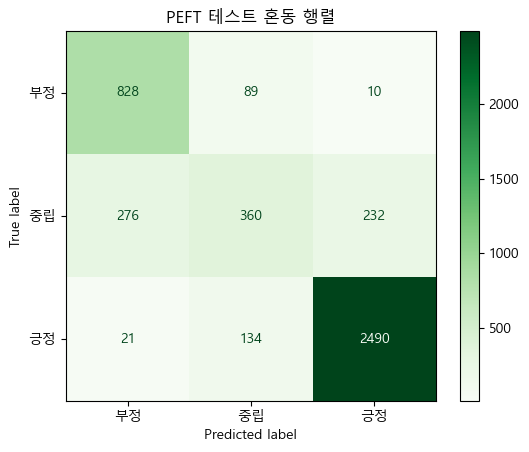

PEFT 주요 오분류 조합:


,실제 라벨,예측 라벨,건수
0,중립,부정,276
1,중립,긍정,232
2,긍정,중립,134
3,부정,중립,89
4,긍정,부정,21
5,부정,긍정,10


PEFT 결과가 비교용 변수에 저장되었습니다.


In [21]:
# 테스트 셋 기준으로 PEFT 모델의 성능을 계산합니다.
peft_pred_ids, peft_true_ids, peft_test_metrics = get_prediction_outputs(trainer_peft, split_name='test')

# 전체 미세조정과 동일한 테스트 라벨 순서를 사용했는지 확인합니다.
assert np.array_equal(test_true_ids, peft_true_ids), '테스트 라벨 순서가 달라졌습니다.'

peft_report = pd.DataFrame(
    classification_report(
        peft_true_ids,
        peft_pred_ids,
        target_names=[ID2LABEL[i] for i in range(len(ID2LABEL))],
        digits=4,
        output_dict=True,
        zero_division=0,
    )
).T
peft_class_metrics = extract_class_report(peft_report)
peft_metric_display = pd.DataFrame([peft_test_metrics]).rename(
    columns={
        'test_loss': '테스트 손실',
        'test_accuracy': '테스트 정확도',
        'test_f1_macro': '테스트 매크로 F1',
        'test_runtime': '평가 시간(초)',
        'test_samples_per_second': '초당 샘플 수',
        'test_steps_per_second': '초당 스텝 수',
    }
)
peft_report_display = peft_report.rename(
    columns={
        'precision': '정밀도',
        'recall': '재현율',
        'f1-score': 'F1',
        'support': '개수',
    },
    index={
        'accuracy': '정확도',
        'macro avg': '매크로 평균',
        'weighted avg': '가중 평균',
    },
)

display(peft_metric_display)
display(peft_class_metrics)
display(peft_report_display)

peft_cm = confusion_matrix(peft_true_ids, peft_pred_ids)
ConfusionMatrixDisplay(
    confusion_matrix=peft_cm,
    display_labels=[ID2LABEL[i] for i in range(len(ID2LABEL))],
).plot(cmap='Greens', values_format='d')
plt.title('PEFT 테스트 혼동 행렬')
plt.show()

peft_confusion_pairs = summarize_confusion_pairs(peft_cm, ID2LABEL)
if not peft_confusion_pairs.empty:
    print('PEFT 주요 오분류 조합:')
    display(peft_confusion_pairs.head(10))
else:
    print('PEFT는 테스트 셋에서 오분류가 없습니다.')

# PEFT 결과를 이후 비교 셀에서 재사용할 수 있게 딕셔너리로 정리합니다.
PEFT_MODEL_SIZE_MB = get_model_file_size_mb(PEFT_EXPORT_DIR)
peft_results = {
    'method': 'PEFT (LoRA 어댑터)',
    'train_seconds': PEFT_TRAIN_SECONDS,
    'accuracy': peft_test_metrics['test_accuracy'],
    'f1_macro': peft_test_metrics['test_f1_macro'],
    'saved_artifact_mb': PEFT_MODEL_SIZE_MB,
    'artifact_scope': '어댑터 가중치만 저장',
}
print('PEFT 결과가 비교용 변수에 저장되었습니다.')


## 14. 예측 샘플 비교

- 이 셀에서 할 일: 실제 리뷰 몇 건을 뽑아 정답 라벨, Full FT 예측, PEFT 예측을 비교합니다.
- 권장 구성: 최소 5건 정도의 리뷰를 선택하고, 각 사례마다 짧은 해석을 붙입니다.
- 특히 한 모델만 틀린 사례와 두 모델이 모두 헷갈린 사례를 나눠 보면, 중립 표현이나 문맥 모호성 같은 어려운 패턴을 설명하기 좋습니다.
- 여기서는 숫자 지표가 보여주지 못하는 차이를 설명하는 역할을 한다고 적어 두면 좋습니다.


In [15]:
# 테스트 셋 리뷰와 두 모델의 예측 결과를 한 표에서 비교합니다.
comparison_source_df = test_df.copy().reset_index(drop=True)
comparison_source_df['true_label_name'] = [ID2LABEL[idx] for idx in test_true_ids]
comparison_source_df['full_pred_name'] = [ID2LABEL[idx] for idx in full_pred_ids]
comparison_source_df['peft_pred_name'] = [ID2LABEL[idx] for idx in peft_pred_ids]
comparison_source_df['full_correct'] = comparison_source_df['true_label_name'] == comparison_source_df['full_pred_name']
comparison_source_df['peft_correct'] = comparison_source_df['true_label_name'] == comparison_source_df['peft_pred_name']

comparison_source_df['case_type'] = np.select(
    [
        (~comparison_source_df['full_correct']) & (~comparison_source_df['peft_correct']),
        (~comparison_source_df['full_correct']) & (comparison_source_df['peft_correct']),
        (comparison_source_df['full_correct']) & (~comparison_source_df['peft_correct']),
        comparison_source_df['full_pred_name'] != comparison_source_df['peft_pred_name'],
    ],
    [
        '둘 다 오답',
        '전체 미세조정만 오답',
        'PEFT만 오답',
        '예측 불일치',
    ],
    default='둘 다 정답',
)

# 두 모델의 판단이 갈리거나 적어도 하나가 틀린 사례를 우선 살펴봅니다.
interesting_cases = comparison_source_df[
    comparison_source_df['case_type'] != '둘 다 정답'
].copy()

# 흥미로운 사례가 너무 적으면 테스트 셋 전체에서 샘플을 뽑습니다.
if len(interesting_cases) < 5:
    interesting_cases = comparison_source_df.copy()

sample_cases = (
    interesting_cases.sample(n=min(5, len(interesting_cases)), random_state=SEED)
    [[
        'review_text',
        'true_label_name',
        'full_pred_name',
        'peft_pred_name',
        'case_type',
        'full_correct',
        'peft_correct',
    ]]
    .rename(
        columns={
            'review_text': '리뷰 텍스트',
            'true_label_name': '정답 라벨',
            'full_pred_name': '전체 미세조정 예측',
            'peft_pred_name': 'PEFT 예측',
            'case_type': '사례 유형',
            'full_correct': '전체 미세조정 정답 여부',
            'peft_correct': 'PEFT 정답 여부',
        }
    )
)
display(sample_cases)


,리뷰 텍스트,정답 라벨,전체 미세조정 예측,PEFT 예측,사례 유형,전체 미세조정 정답 여부,PEFT 정답 여부
1507,긴끈이 없었군요ㅠ 다른건 다 맘에들어요..크기가 적당해요,긍정,중립,중립,둘 다 오답,False,False
4145,기모가 두껍지않아서 많이 따뜻하진않습니다. 딸이랑 입으려고 26을 주문했습니다. 평소 사이즈가 25-26사이라서 클까 걱정을했는데 딸도저도 잘맞습니다. 세가지 모두 핏도 색깔도 맘에드네요.,중립,긍정,긍정,둘 다 오답,False,False
93,제 사이즈가없어서 걍 제 사이즈가까운 재고사이즈로 주문했는데 한치수크게 주문했는데 잘한듯싶네요 정사이즈로 했음 허리가 불편했을듯싶어요 바지는 따뜻하네요 저한텐 기장이살짝 길어요 핏은그닥별루 가격저렴하게 잘 구입한거같아요,긍정,중립,중립,둘 다 오답,False,False
4030,재질은 정말 맘에 들어요 사이즈는 제각각 다르구요 어떤건 딱 맞구 어떤건 너무 크게 나왔구 교환신청한건 비슷하게 오길 바랄 뿐이예요 색상은 화면보다 어두워서 이상해요,부정,중립,부정,전체 미세조정만 오답,False,True
1341,보통 28입는데 27주문했는데도 커요 입으면 편하긴 합니다 흰색으로 26하나더 주문하려고 합니다,긍정,중립,중립,둘 다 오답,False,False


## 15. 두 방식 비교 분석

- 이 셀에서 할 일: Full Fine-Tuning과 PEFT를 표 형태 또는 문장 형태로 직접 비교합니다.
- 꼭 포함할 내용: 어떤 방식이 더 빨랐는지, 어떤 방식이 더 가벼웠는지, 성능 차이는 어느 정도였는지.
- 다만 Full FT 저장 용량은 전체 가중치 기준이고, PEFT 저장 용량은 adapter artifact 기준일 수 있으므로 같은 의미의 숫자인지 해석을 분리해서 적는 것이 중요합니다.
- 마지막에는 이번 과제 기준에서 어느 방식이 더 실용적이라고 보는지 자신의 판단을 적습니다.


,방식,학습 시간(초),학습 시간(분),정확도,매크로 F1,저장 아티팩트(MB),아티팩트 범위
0,전체 미세조정 (Full FT),443.986301,7.399772,0.886261,0.847068,416.145204,전체 모델 가중치
1,PEFT (LoRA 어댑터),548.304763,9.138413,0.828378,0.743131,3.965402,어댑터 가중치만 저장


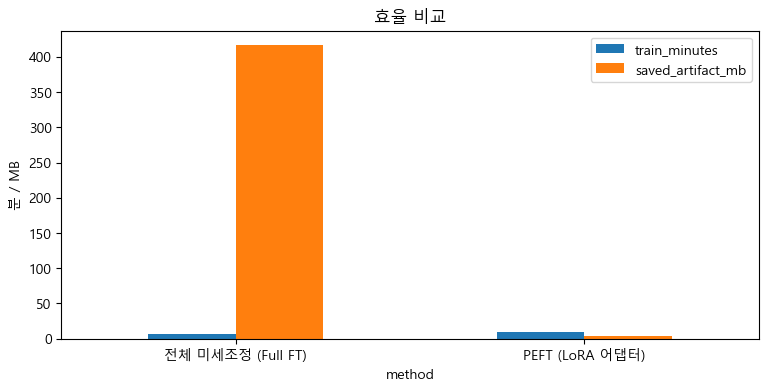

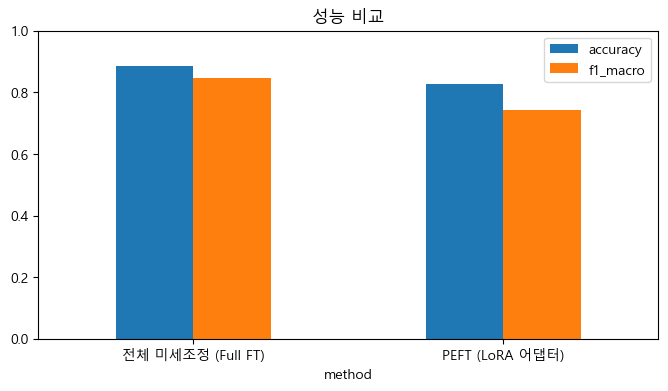

,라벨,전체 미세조정 F1,PEFT F1
0,긍정,0.947109,0.926167
1,부정,0.868843,0.807018
2,중립,0.725250,0.496210


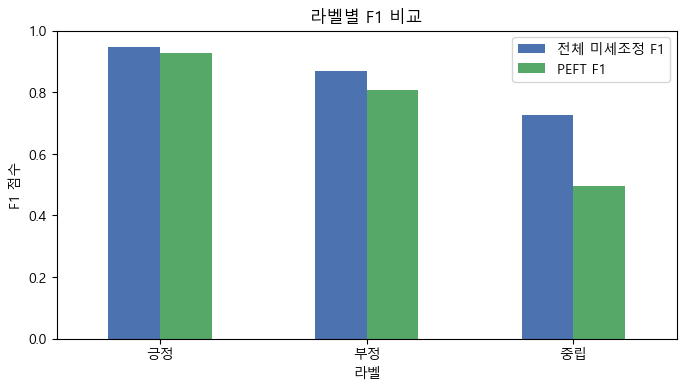

해석 메모:
- 전체 미세조정 저장 용량은 전체 모델 가중치 아티팩트 기준입니다.
- PEFT 저장 용량은 LoRA 어댑터 아티팩트 기준입니다.
- backbone을 재사용하는 배포 상황에서는 PEFT의 추가 저장 비용이 작지만, 최초 전체 배포 크기는 backbone 크기도 함께 고려해야 합니다.


In [22]:
# 전체 미세조정과 PEFT의 핵심 수치를 한 표로 모읍니다.
comparison_df = pd.DataFrame([full_results, peft_results])
comparison_df['train_minutes'] = comparison_df['train_seconds'] / 60
comparison_df = comparison_df[
    ['method', 'train_seconds', 'train_minutes', 'accuracy', 'f1_macro', 'saved_artifact_mb', 'artifact_scope']
]
comparison_display_df = comparison_df.rename(
    columns={
        'method': '방식',
        'train_seconds': '학습 시간(초)',
        'train_minutes': '학습 시간(분)',
        'accuracy': '정확도',
        'f1_macro': '매크로 F1',
        'saved_artifact_mb': '저장 아티팩트(MB)',
        'artifact_scope': '아티팩트 범위',
    }
)
display(comparison_display_df)

# 효율 비교: 학습 시간과 저장 아티팩트 크기를 막대그래프로 봅니다.
ax = comparison_df.set_index('method')[['train_minutes', 'saved_artifact_mb']].plot(
    kind='bar',
    figsize=(9, 4),
    rot=0,
)
ax.set_title('효율 비교')
ax.set_ylabel('분 / MB')
plt.show()

# 성능 비교: 정확도와 매크로 F1을 막대그래프로 봅니다.
ax = comparison_df.set_index('method')[['accuracy', 'f1_macro']].plot(
    kind='bar',
    figsize=(8, 4),
    rot=0,
)
ax.set_title('성능 비교')
ax.set_ylim(0, 1.0)
plt.show()

# 클래스별 F1을 비교해 어떤 라벨에서 차이가 나는지도 함께 확인합니다.
class_f1_comparison_df = (
    full_class_metrics[['라벨', 'F1']]
    .rename(columns={'F1': '전체 미세조정 F1'})
    .merge(
        peft_class_metrics[['라벨', 'F1']].rename(columns={'F1': 'PEFT F1'}),
        on='라벨',
        how='outer',
    )
)
display(class_f1_comparison_df)

ax = class_f1_comparison_df.set_index('라벨')[['전체 미세조정 F1', 'PEFT F1']].plot(
    kind='bar',
    figsize=(8, 4),
    rot=0,
    color=['#4c72b0', '#55a868'],
)
ax.set_title('라벨별 F1 비교')
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1 점수')
plt.show()

print('해석 메모:')
print('- 전체 미세조정 저장 용량은 전체 모델 가중치 아티팩트 기준입니다.')
print('- PEFT 저장 용량은 LoRA 어댑터 아티팩트 기준입니다.')
print('- backbone을 재사용하는 배포 상황에서는 PEFT의 추가 저장 비용이 작지만, 최초 전체 배포 크기는 backbone 크기도 함께 고려해야 합니다.')


## 16. 최종 결론과 회고

- 이 셀에서 할 일: 이번 실험 전체를 짧게 마무리합니다.
- 포함할 내용: 사용 데이터, 사용 모델, 핵심 결과, 느낀 점, 다음에 개선하고 싶은 점.
- 특히 PEFT 저장 용량은 adapter 기준이라는 점, 그리고 노트북 커널과 패키지 버전 차이가 재현성에 영향을 줄 수 있었다는 점까지 같이 회고하면 제출 완성도가 더 좋아집니다.
- 예를 들면 다른 도메인 확장, 하이퍼파라미터 조정, 오분류 분석 강화 같은 후속 아이디어를 적을 수 있습니다.


In [17]:
# 최종 결론 마크다운 셀에 옮겨 적기 쉽도록 핵심 수치를 한 번 더 정리합니다.
summary_lines = [
    f'- 사용 데이터: {SOURCE_NAME} / {DOMAIN_NAME}',
    f'- 전체 샘플 수: {len(df_model):,}',
    f'- 학습 / 검증 / 테스트: {len(train_df):,} / {len(valid_df):,} / {len(test_df):,}',
    (
        f"- 전체 미세조정: 정확도={full_results['accuracy']:.4f}, "
        f"매크로 F1={full_results['f1_macro']:.4f}, "
        f"학습 시간={full_results['train_seconds'] / 60:.2f}분, "
        f"저장 아티팩트={full_results['saved_artifact_mb']:.2f}MB ({full_results['artifact_scope']})"
    ),
    (
        f"- PEFT: 정확도={peft_results['accuracy']:.4f}, "
        f"매크로 F1={peft_results['f1_macro']:.4f}, "
        f"학습 시간={peft_results['train_seconds'] / 60:.2f}분, "
        f"저장 아티팩트={peft_results['saved_artifact_mb']:.2f}MB ({peft_results['artifact_scope']})"
    ),
    '- 해석 주의: PEFT 저장 용량은 어댑터만 따로 저장한 값이며, 최초 전체 배포 크기와는 다를 수 있습니다.',
]

if 'env_df' in globals():
    missing_packages = env_df.loc[~env_df['installed'], 'package'].tolist()
    if missing_packages:
        summary_lines.append(f"- 환경 점검: 현재 커널에 누락 패키지 {', '.join(missing_packages)}")
    else:
        summary_lines.append('- 환경 점검: 필수 패키지 확인 완료')

if 'full_confusion_pairs' in globals() and not full_confusion_pairs.empty:
    top_full_confusion = full_confusion_pairs.iloc[0]
    summary_lines.append(
        f"- 전체 미세조정 주요 오분류: {top_full_confusion['실제 라벨']} -> {top_full_confusion['예측 라벨']} ({top_full_confusion['건수']}건)"
    )

if 'peft_confusion_pairs' in globals() and not peft_confusion_pairs.empty:
    top_peft_confusion = peft_confusion_pairs.iloc[0]
    summary_lines.append(
        f"- PEFT 주요 오분류: {top_peft_confusion['실제 라벨']} -> {top_peft_confusion['예측 라벨']} ({top_peft_confusion['건수']}건)"
    )

for line in summary_lines:
    print(line)


- 사용 데이터: 쇼핑몰 / 01. 패션
- 전체 샘플 수: 44,396
- 학습 / 검증 / 테스트: 35,516 / 4,440 / 4,440
- 전체 미세조정: 정확도=0.8863, 매크로 F1=0.8471, 학습 시간=7.40분, 저장 아티팩트=416.15MB (전체 모델 가중치)
- PEFT: 정확도=0.8284, 매크로 F1=0.7431, 학습 시간=9.14분, 저장 아티팩트=3.97MB (어댑터 가중치만 저장)
- 해석 주의: PEFT 저장 용량은 어댑터만 따로 저장한 값이며, 최초 전체 배포 크기와는 다를 수 있습니다.
- 환경 점검: 필수 패키지 확인 완료
- 전체 미세조정 주요 오분류: 긍정 -> 중립 (140건)
- PEFT 주요 오분류: 중립 -> 부정 (276건)
